In [1]:
import os
import math
import numpy as np 
import pandas as pd 
import kmeans as km
import transition as tr
import segmentation as sg
import validation_model as vm
import dbscan_clustering as db
import adjectives_handle as ah
import data_processing.src.plot as plot

from data_processing.src import config

# 0. Initial Parameters Selection 

1. Choose the Target Activity to be learned: "sphereActivity", "ladderActivity", "trashActivity", "pilotActivity".
2. Select the Segmentation Threshold: it is a *trail and error* approach based on the expected number of segments. 
3. Select the Normalization Scaler.
4. Choose the Features on which to perform training. 

In [2]:
TARGET_ACTIVITY = "sphereActivity"
TEST_ACTIVITY = "sphereActivity"
K_VALUE = 10

target_activity = TARGET_ACTIVITY 
threshold = 0.7
scaler = "standard"


# only rotation
"""result_directory = "dbscan_results_rotation"
features = config.ROTATION_FEATURES
segmentation_result = config.ROTATION_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.ROTATION_HISTOGRAMS_DIR"""

# only position
"""result_directory = "dbscan_results_position"
features = config.POSITION_FEATURES
segmentation_result = config.POSITION_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.POSITION_HISTOGRAMS_DIR"""

# both rotation and position
features = config.FEATURES
segmentation_result = config.BOTH_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.BOTH_HISTOGRAMS_DIR

feature_len = len(features) - 2 

clustering_algorithm = "kmeans" #"kmeans"

# Model Training

The training is divided into three steps: 
1. Segmentation of the Target Action into Elementary Actions.
2. Clustering of Elementary Actions.
3. Processing of the Markov Chain.

## 1 Target Activity Segmentation

1. Perform the Segmentation process and evaluate the histogram.
2. Adjust the *Threshold* (Step 0) to obtain an appropriate number of segments per log.

Loading existing segmentation data for sphereActivity (threshold=0.7, scaler=standard)...
  RSV file: /Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/results/both_segmentation/right_singular_vector/sphereActivity/standard/rsv_sphereActivity_0.7_standard.csv
  LSV file: /Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/results/both_segmentation/left_singular_vector/sphereActivity/standard/lsv_sphereActivity_0.7_standard.pkl
Segmentation data loaded successfully!
  - RSV DataFrame shape: (1157, 21)
  - Number of users in LSV: 23


,Username,Adjective,LogNumber,RSV_1,RSV_2,RSV_3,RSV_4,RSV_5,RSV_6,RSV_7,...,RSV_9,RSV_10,RSV_11,RSV_12,RSV_13,RSV_14,RSV_15,RSV_16,RSV_17,RSV_18
0,grims2,0.087721,1,-0.103421,-0.173569,-0.037947,-0.059950,-0.025318,0.002415,0.032706,...,0.012774,-0.048834,0.033027,-0.163502,0.003085,-0.480829,0.023977,0.553108,0.245938,0.537722
1,grims2,0.058289,1,-0.103421,-0.173569,-0.037947,-0.059950,-0.025318,0.002415,0.032706,...,0.012774,-0.048834,0.033027,-0.163502,0.003085,-0.480829,0.023977,0.553108,0.245938,0.537722
2,grims2,-0.021423,1,-0.103421,-0.173569,-0.037947,-0.059950,-0.025318,0.002415,0.032706,...,0.012774,-0.048834,0.033027,-0.163502,0.003085,-0.480829,0.023977,0.553108,0.245938,0.537722
3,grims2,-0.333016,1,-0.288337,0.243723,0.202663,0.010234,0.249114,-0.217215,-0.303002,...,0.214014,0.046558,0.198409,0.049563,-0.268186,0.315315,-0.354205,-0.256303,0.228148,-0.298872
4,grims2,0.038720,2,-0.303071,0.226340,0.229409,0.013287,0.214252,-0.199047,-0.297286,...,0.199907,0.256055,0.227557,0.077128,-0.319590,0.325631,-0.289519,-0.217705,0.249221,0.204703


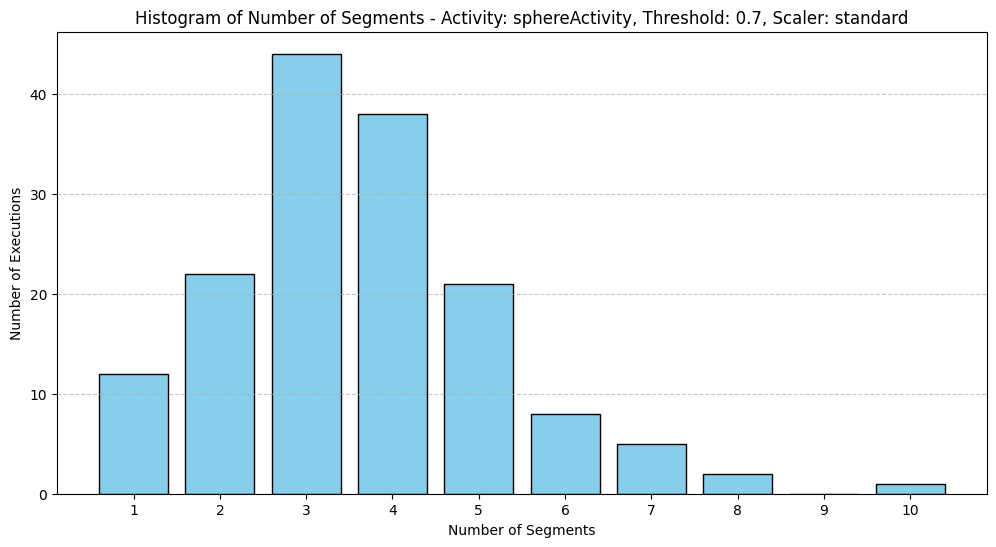

In [3]:
rsv_df, lsv_all_user = sg.get_or_compute_segmentation(
            activity=target_activity,
            features=features,
            threshold=threshold,
            scaler=scaler,
            filepath=segmentation_result
        )

display(rsv_df.head())

os.makedirs(segmentation_result + f"/segments_number/{target_activity}", exist_ok=True)
os.makedirs(histogram_dir + f"/{target_activity}", exist_ok=True)

plot.plot_histogram_of_segments(
    filepath=segmentation_result + f"/segments_number/{target_activity}/{scaler}/segmentation_results_{target_activity}_{threshold}_{scaler}.csv",
    savepath=histogram_dir + f"/{target_activity}")


## 2 Elementary Actions Clustering 

Apply the DBSCAN or KMEANS clustering algorithm to define the most generalised representation of each elementary action (*substantives*).

In [4]:
rsv_path = segmentation_result + f"/right_singular_vector/{target_activity}/{scaler}/rsv_{target_activity}_{threshold}_{scaler}.csv"

In [5]:
print(f"===== Processing activity: {target_activity}, threshold: {threshold}, scaler: {scaler} =====\n")

df_origin = pd.read_csv(rsv_path, index_col=None)

df = df_origin.drop(columns=['Username', "Adjective", 'LogNumber'])
df = df.dropna()
df = df.drop_duplicates()

print("=================================================\n")

===== Processing activity: sphereActivity, threshold: 0.7, scaler: standard =====




### 2.1 Initial Plots 

In [6]:
#db.initial_plot(df)
#features = ['RSV_1', 'RSV_2', 'RSV_4']
#display(df.head())
#plot.plot_three_columns(df, 'RSV_1', 'RSV_2', 'RSV_3', title="RSV 1, 2, 4 distribution", plot_type='3d_scatter')

#db.pair_plot(df)

### 2.2 GRID for Hyperparameters

Choose the best combination of the hyperparameters following these rules: 
1. Avoid the presence of a cluster that is considerably larger than the others.
2. Avoid having more than half of all elementary actions being outliers.
3. Accept solutions in which there are at least two clusters that are larger than the others.
4. Choose solutions with an appropriate number of clusters (neither too few nor too many).

If you are unsure between two solutions, choose the one that produces fewer clusters.

== KMEANS Clustering Results ==

Number of columns: 18
Length of DataFrame: 523

 ITER| INFO               | CLUS |   Cluster Size
--------------------------------------------------
   1 | Tested with K =   1|   1  |  None
   2 | Tested with K =   2|   2  | C0: 266, C1: 257
   3 | Tested with K =   3|   3  | C0: 149, C1: 168, C2: 206
   4 | Tested with K =   4|   4  | C0: 123, C1: 149, C2: 107, C3: 144
   5 | Tested with K =   5|   5  | C0: 81, C1: 116, C2: 98, C3: 127, C4: 101
   6 | Tested with K =   6|   6  | C0: 69, C1: 64, C2: 93, C3: 92, C4: 93, C5: 112
   7 | Tested with K =   7|   7  | C0: 64, C1: 52, C2: 77, C3: 90, C4: 89, C5: 104, C6: 47
   8 | Tested with K =   8|   8  | C0: 51, C1: 69, C2: 32, C3: 75, C4: 66, C5: 79, C6: 70, C7: 81
   9 | Tested with K =   9|   9  | C0: 47, C1: 64, C2: 52, C3: 51, C4: 52, C5: 70, C6: 56, C7: 72, C8: 59
  10 | Tested with K =  10|  10  | C0: 50, C1: 49, C2: 47, C3: 55, C4: 42, C5: 51, C6: 57, C7: 73, C8: 60, C9: 39
  11 | Tested with K =  1

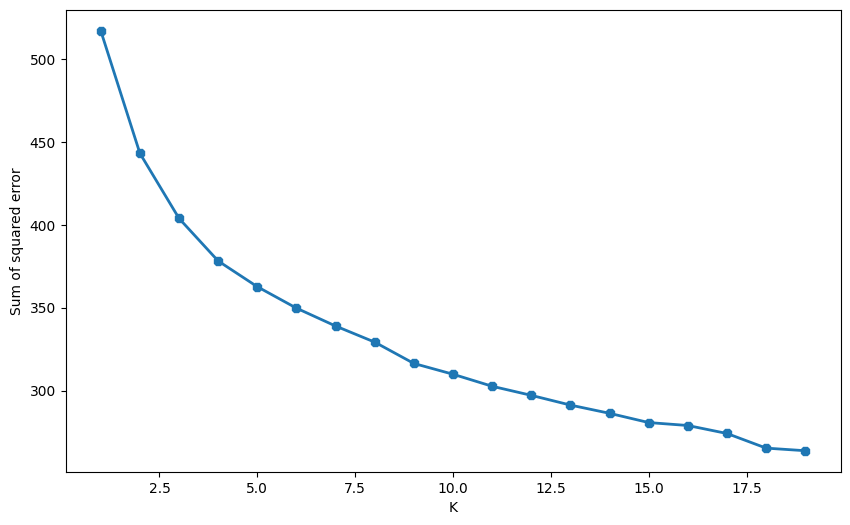

In [7]:
"""pca = PCA(n_components=0.9)

X_pca = pca.fit_transform(df.values)

# Trasforma in DataFrame con indici originali
df_pca = pd.DataFrame(X_pca, index=df.index, columns=[f'{i+1}' for i in range(X_pca.shape[1])])
"""

if clustering_algorithm == "dbscan": 
    print("== DBSCAN Clustering Results ==\n")
    n_cols = len(df.columns)
    length = len(df)
    print(f"Number of columns: {n_cols}\nLength of DataFrame: {length}\n")
    db.grid(df)
elif clustering_algorithm == "kmeans":
    print("== KMEANS Clustering Results ==\n")
    n_cols = len(df.columns)
    length = len(df)
    print(f"Number of columns: {n_cols}\nLength of DataFrame: {length}\n")
    km.grid(df)

### 2.3 Hyperparameter Selection and Clustering Execution 

Enter the chosen values for *eps* and *min_samples* (Step 2.2).

In [8]:
if clustering_algorithm == "dbscan":
    eps = 0.25
    min_samples = 11
elif clustering_algorithm == "kmeans":
    K = K_VALUE
    # K = 10

In [9]:
if clustering_algorithm == "dbscan":
    best_labels = db.dbscan_clustering(df, eps=eps, min_samples=min_samples)
    df['Label'] = best_labels
    #df_pca['Label'] = best_labels

    #db.pair_plot_cluster(df_pca)

    # add the labels to df_origin handling the duplicates rows 
    feature_cols = df_origin.columns[-18:].to_list()

    df_origin = df_origin.merge(
        df,
        on=feature_cols,
        how="left"
    )
    result_directory = "dbscan_results"
    dbscan_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/all_points/"
    os.makedirs(dbscan_dir, exist_ok=True)
    save_dir = dbscan_dir + f"dbscan_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"

    os.makedirs(os.path.dirname(save_dir), exist_ok=True)
    df_origin.to_csv(save_dir, index=False)

    df_no_outliers = df.drop(df[df['Label'] == -1].index)
    unique_labels = df_no_outliers['Label'].unique()

    print(f"Number of unique labels (excluding outliers): {len(unique_labels)}\n")

In [10]:
if clustering_algorithm == "kmeans":
    best_labels = km.kmeans_with_outlier_detection(df=df, K=K)
    df['Label'] = best_labels

    feature_cols = df_origin.columns[-18:].to_list()

    df_origin = df_origin.merge(
        df,
        on=feature_cols,
        how="left"
    )
    result_directory = "kmeans_results"
    kmeans_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/all_points/"
    os.makedirs(kmeans_dir, exist_ok=True)

    save_dir = kmeans_dir + f"kmeans_{target_activity}_{threshold}_{scaler}_k{K}.csv"

    os.makedirs(os.path.dirname(save_dir), exist_ok=True)
    df_origin.to_csv(save_dir, index=False)

    df_no_outliers = df.drop(df[df['Label'] == -1].index)
    unique_labels = df_no_outliers['Label'].unique()

    print(f"Number of unique labels (excluding outliers): {len(unique_labels)}\n")


Number of unique labels (excluding outliers): 5



### 2.4 Printing and Saving Results.

The set of elementary actions is the *dictionary of substantives*.

Each *substantives* is characterised by an *adjective* that represents its speed. Together, they make up the *dictionary of adjectives*.

In [11]:
df_substantives = db.get_substantives_dataframe(df=df_no_outliers, unique_labels=unique_labels)
print("\n== Substantives DataFrame ==\n")
display(df_substantives)
if clustering_algorithm == "dbscan":
    save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/substantives/substantives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
elif clustering_algorithm == "kmeans":
    save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/substantives/substantives_{target_activity}_{threshold}_{scaler}_k{K}.csv"
os.makedirs(os.path.dirname(save_dir), exist_ok=True)

df_substantives.to_csv(save_dir, index=False)


== Substantives DataFrame ==



,Label,RSV_1,RSV_2,RSV_3,RSV_4,RSV_5,RSV_6,RSV_7,RSV_8,RSV_9,RSV_10,RSV_11,RSV_12,RSV_13,RSV_14,RSV_15,RSV_16,RSV_17,RSV_18
0,5,0.089609,-0.201098,0.065298,0.175942,-0.015253,0.035961,0.131690,-0.273847,0.201114,0.001531,0.114990,-0.066541,-0.027392,-0.127386,0.015310,-0.048814,0.031953,0.087416
1,3,-0.271804,0.105904,0.121611,-0.014570,0.212686,-0.140411,-0.253673,0.145195,0.175432,0.226453,0.186155,0.041511,-0.262007,0.103012,-0.124275,-0.032349,0.198236,-0.049973
2,7,0.254042,0.261795,-0.112999,-0.006841,-0.120975,0.027204,0.173577,0.213018,-0.102348,0.045267,-0.102972,0.159248,0.152004,0.157684,-0.015455,-0.104378,-0.020017,-0.184172
3,6,-0.250877,0.016499,-0.188815,0.038616,0.252847,0.095853,-0.182354,-0.005523,-0.101740,-0.042077,0.128611,-0.047569,-0.195224,0.158844,-0.253087,0.112569,0.136968,-0.075805
4,8,-0.217811,0.155626,0.248505,-0.066724,0.156213,-0.038290,-0.147748,0.136988,0.053568,-0.097957,0.028150,0.067410,-0.282241,0.068794,0.369275,0.143631,0.049162,-0.125697


## 2.5 Adjectives Dictionary Management

In the segmentation in Section 1, all left singular vectors (lsv) corresponding to right singular vectors (rsv) were also retrieved. 
*lsv_all_user* is a multiple dictionary in which the first key is the username, the second key is the log number, and the third key discriminates between the various lsv. 
Now we need to manipulate this information:
- **ah.adjective_dict()**. This allows us to create a dictionary that groups the various lsv according to the cluster to which the associated right singular vector belongs. 
- **ah.adjectives_segmentation()**. This allows you to segment the lsv in each cluster into four possible categories (slow_pos, slow_neg, fast_pos, fast_neg) based on two thresholds set at 0.2 and -0.2. The resulting dict will have the cluster as the first key and the category as the second key. Each category contains all the lsv belonging to it.
- **ah.generalize_adjectives()**. Generalises the left singular vectors of each cluster and each category with a value. At the end, we obtain a DataFrame where each row contains the cluster, the category and the representative value: each cluster will have at most 4 adjectives, one per category.


In [12]:
# Create LSV clusters dictionary based on DBSCAN results
df_new = df_origin.drop(columns=['Adjective']).drop_duplicates()

# Obtain a dict where the key is the cluster label and the value are lsv
lsv_clusters_dict = ah.adjectives_dict(best_labels, lsv_all_user, df_new)

# Obtain a dict where the key is the cluster label and the value are segments of lsv (slow positive, slow negative, fast positive, fast negative)
clusters_dict = ah.adjectives_segmentation(lsv_clusters_dict)

# Obtain a DataFrame with the label and the adjective(s) mean value for each segment
df_adjectives = ah.generalize_adjectives(clusters=clusters_dict)

print("\n== Adjectives DataFrame ==\n")
display(df_adjectives)

save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/adjectives/"
os.makedirs(os.path.dirname(save_dir), exist_ok=True)

if clustering_algorithm == "dbscan":
    adj_dir = save_dir + f"adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
elif clustering_algorithm == "kmeans":
    adj_dir = save_dir + f"adjectives_{target_activity}_{threshold}_{scaler}_k{K}.csv"

df_adjectives.to_csv(adj_dir, index=False)

Creating LSV clusters dictionary...

== Adjectives DataFrame ==



,Label,Adjective
0,3,0.028620
1,3,-0.081582
2,3,0.381781
3,3,-0.258906
4,5,0.048266
5,5,-0.083907
6,5,0.252783
7,5,-0.231213
8,6,0.040195
9,6,-0.095127


## 3. Markov Chain: States Transactions

A state in the *Markov Chain* is given by the pair of a *substantive* and one of its corresponding *adjectives*.

Define all possible states and calculate the probability of each state transition based on how the elementary actions obtained from the training data follow one another.

Average: 8.03
Total sequences: 144
Minimum sequence length: 1
Maximum sequence length: 22

== Transition Matrix: ==


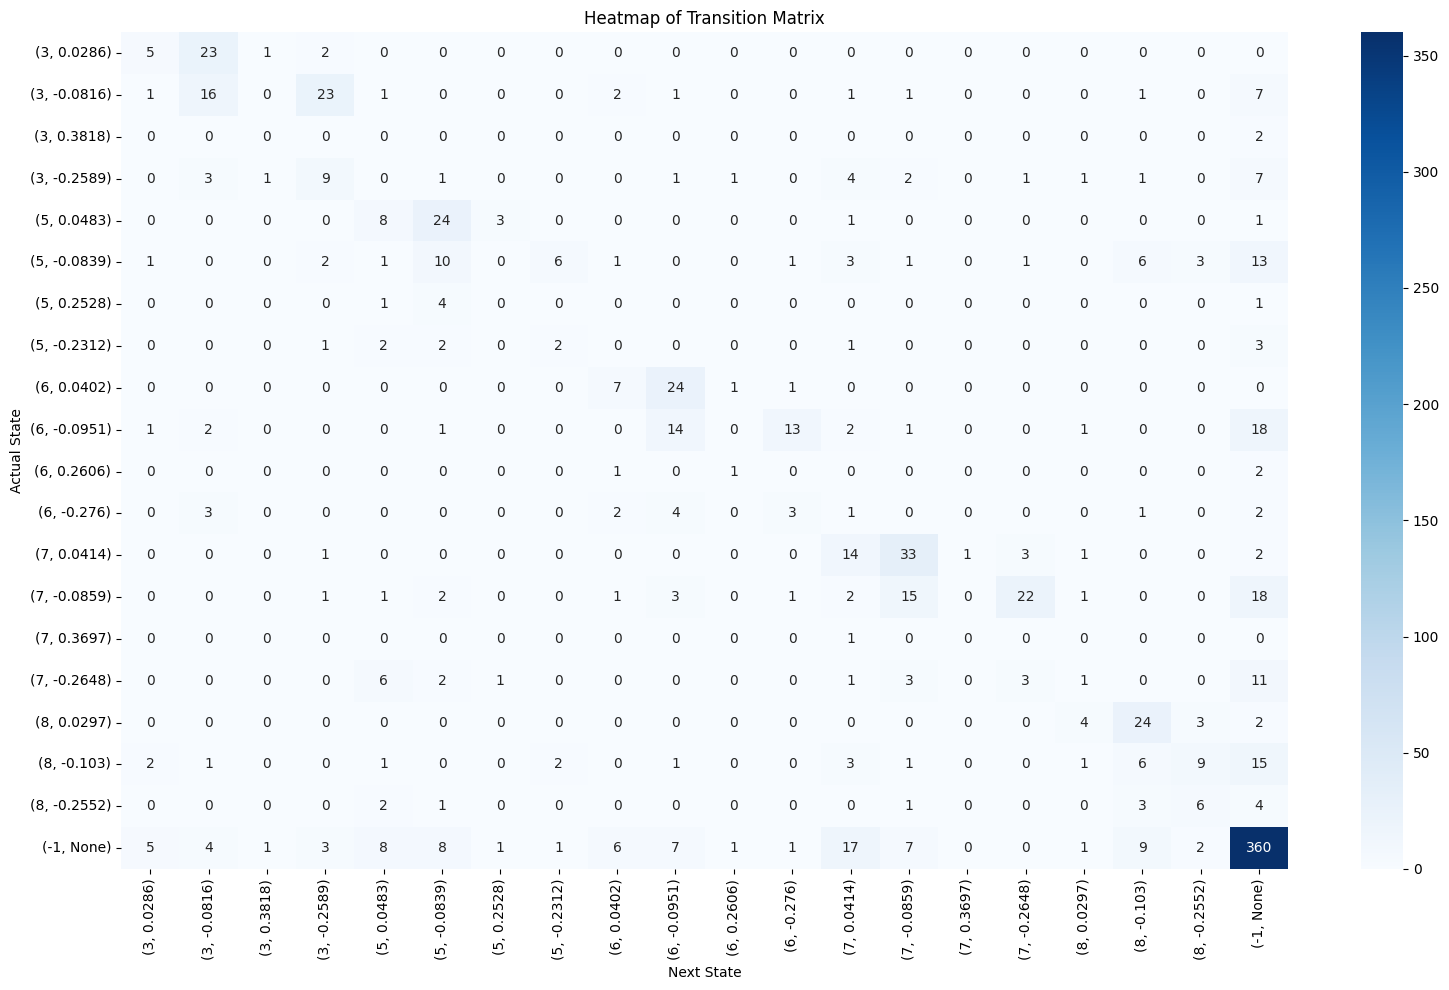


== Transition Probabilities: ==


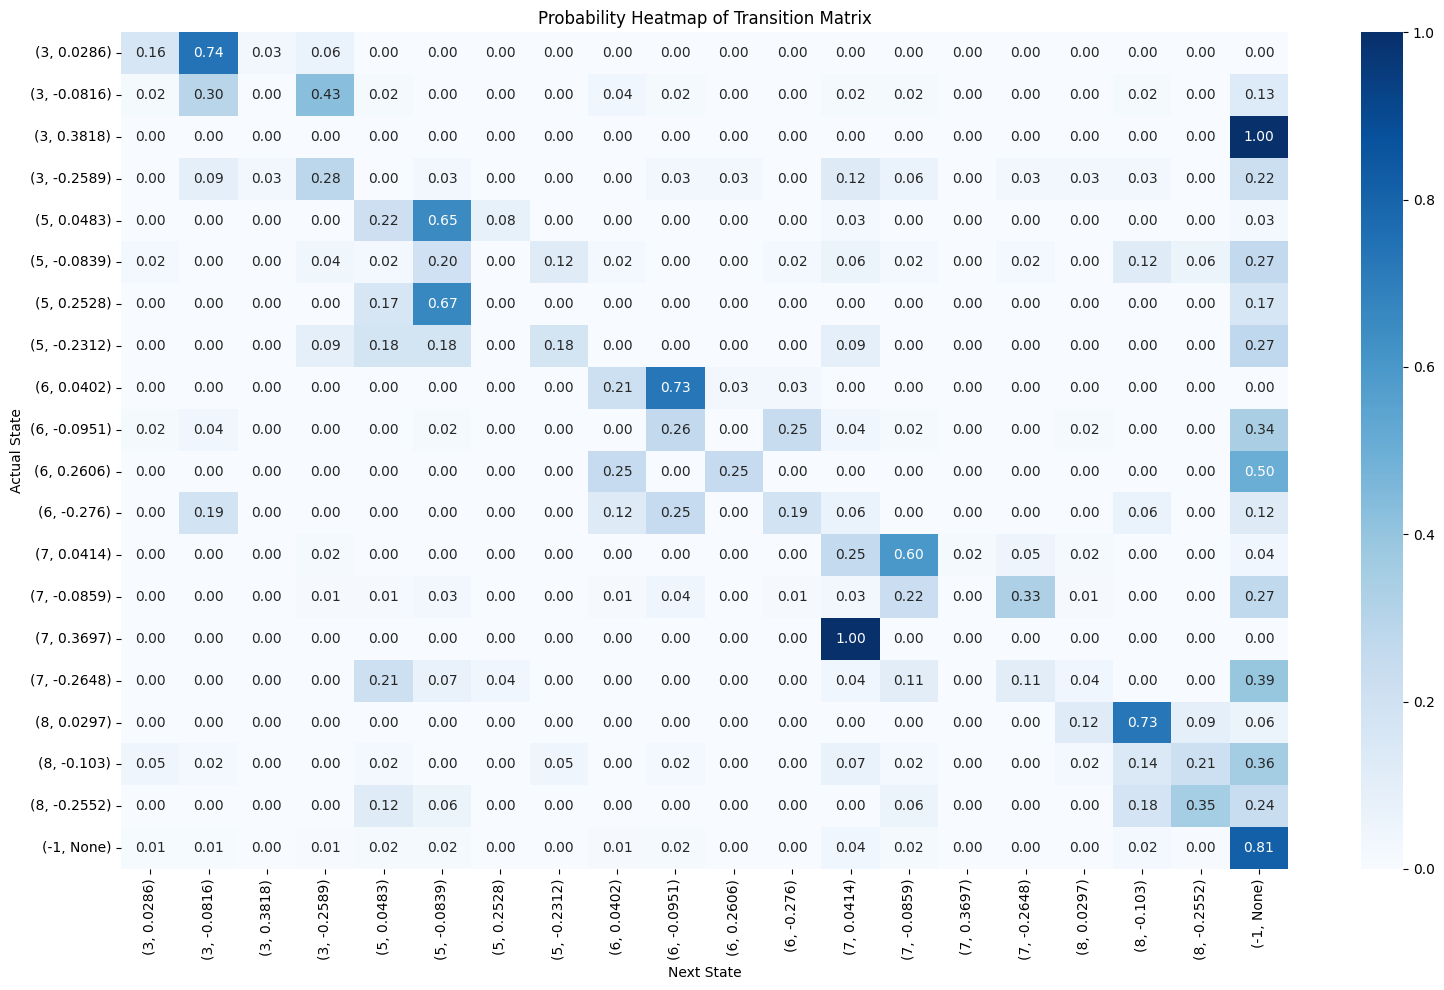


Transition results saved in /Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/results/transition_results/sphereActivity/standard


,State,Initial_Probability
0,"(3, 0.0286)",0.111111
1,"(3, -0.0816)",0.055556
2,"(3, 0.3818)",0.000000
3,"(3, -0.2589)",0.000000
4,"(5, 0.0483)",0.041667
5,"(5, -0.0839)",0.000000
6,"(5, 0.2528)",0.006944
7,"(5, -0.2312)",0.000000
8,"(6, 0.0402)",0.090278
9,"(6, -0.0951)",0.069444


Index(['(3, 0.0286)', '(3, -0.0816)', '(3, 0.3818)', '(3, -0.2589)',
       '(5, 0.0483)', '(5, -0.0839)', '(5, 0.2528)', '(5, -0.2312)',
       '(6, 0.0402)', '(6, -0.0951)', '(6, 0.2606)', '(6, -0.276)',
       '(7, 0.0414)', '(7, -0.0859)', '(7, 0.3697)', '(7, -0.2648)',
       '(8, 0.0297)', '(8, -0.103)', '(8, -0.2552)', '(-1, None)'],
      dtype='object')

In [13]:
if clustering_algorithm == "dbscan":
    df_transition, df_probs, df_initial, sequence_stats = tr.transition_computation_dbscan(
            activity=target_activity,
            scaler=scaler,
            threshold=threshold,
            eps=eps,
            min_samples=min_samples,
            file_path=processed_data_path + f"/{result_directory}/{target_activity}/{scaler}"
        )
elif clustering_algorithm == "kmeans":
    df_transition, df_probs, df_initial, sequence_stats = tr.transition_computation_kmeans(
            activity=target_activity,
            scaler=scaler,
            threshold=threshold,
            k=K,
            file_path=processed_data_path + f"/{result_directory}/{target_activity}/{scaler}"
        )

display(df_initial)
display(df_transition.columns)


# Model Validation 

1. Select the user from whom you want to retrieve the activity on which to validate the model.
2. Select the activity on which to validate.

In [14]:
#username = "grims3"
#test_activity = "ladderActivity"  
test_activity = TEST_ACTIVITY
#file_path = config.find_file_from_username(username)
#file_path = config.find_file_from_username_and_basepath(username=username, base_path=config.RAW_DATA_DIR + "/test_data")
#print(file_path)

files = config.get_all_files_from_basepath(base_path=config.TEST_DATA_DIR)
for file in files: 
    print(f"{file} \n")

/Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/raw/test_data/grims3/grims3_log_20250719_1247_3L2OXWTATJ.csv 

/Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/raw/test_data/SADAX/SADAX_log_20250701_1140_VHH2PVVLXA.csv 



## 1. Test Activity Segmentation

Select the threshold for segmentation.

Note: if the test activity is the same as the train activity, choose the same threshold as the train (Step 0).

In [15]:
new_threshold = threshold

rsv_df = pd.DataFrame()
lsv_users = {}

for file in files: 
    username = str(file).split("/")[-1].split("_")[0]
    print(f"===== Segmentating user: {username}, test_activity: {test_activity}, scaler: {scaler}, threshold: {new_threshold} =====")
    rsv_user, lsv_user = vm.segment_user(username=username, file_path=file, features=features, activity=test_activity, scaler=scaler, threshold=new_threshold)
    rsv_df = pd.concat([rsv_df, rsv_user], ignore_index=True)
    lsv_users[username] = lsv_user


#rsv_df, lsv_user = vm.segment_user(username=username, file_path=file_path, features=features, activity=test_activity, scaler=scaler, threshold=new_threshold)

print("\n== RSV DataFrame: ==")
display(rsv_df)


===== Segmentating user: grims3, test_activity: sphereActivity, scaler: standard, threshold: 0.7 =====
Data successfully loaded - Shape: (8919, 22)
Rotation features normalized
Position features normalized
===== Segmentating user: SADAX, test_activity: sphereActivity, scaler: standard, threshold: 0.7 =====
Data successfully loaded - Shape: (16070, 22)
Rotation features normalized
Position features normalized

== RSV DataFrame: ==


,Username,LogNumber,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,grims3,1.0,-0.103004,-0.173544,-0.016804,-0.001421,-0.032193,-0.029900,0.071450,-0.203456,-0.025929,-0.057314,0.028860,-0.232812,0.025419,-0.454700,0.010916,0.364996,0.210135,0.683133
1,grims3,2.0,-0.270594,0.110019,0.312418,0.006935,0.287016,-0.303236,-0.282826,0.156082,0.287723,0.365782,0.271641,0.093178,-0.283110,0.239286,0.011166,-0.133739,0.234889,0.169392
2,grims3,2.0,0.308043,0.256985,-0.137560,-0.032028,-0.044084,0.129071,0.100994,0.298415,-0.063691,-0.081093,-0.270654,0.366317,-0.019201,0.136938,-0.045255,-0.270757,-0.112564,-0.613224
3,grims3,2.0,-0.066773,0.370544,0.283599,0.163424,0.146010,-0.048825,-0.257169,0.421016,0.194950,0.065084,-0.060731,0.450718,-0.273328,0.005680,-0.034107,-0.326328,0.177068,-0.145555
4,grims3,2.0,0.251887,-0.207898,-0.262435,-0.057180,-0.279623,0.234642,0.334233,-0.178742,-0.228398,0.031773,-0.221892,-0.051297,0.226055,-0.276364,0.014551,0.268559,-0.033707,0.488151
5,grims3,3.0,-0.267006,0.125196,0.281788,0.005660,0.271443,-0.269341,-0.252070,0.157522,0.253185,0.384230,0.229874,0.115451,-0.221196,0.269423,0.057974,-0.201235,0.085173,-0.385339
6,grims3,3.0,0.416531,0.236816,-0.260092,0.029749,-0.224898,0.200253,0.115441,0.219116,-0.199485,-0.089058,-0.260135,0.156953,0.186497,0.306403,-0.172783,-0.253391,-0.391112,0.184780
7,grims3,3.0,-0.171965,0.305317,0.303374,0.154613,0.323127,-0.179813,-0.305806,0.261598,0.332555,0.013138,0.247505,0.067746,-0.321888,0.316218,0.102166,-0.215370,0.158948,-0.016360
8,grims3,4.0,-0.306013,0.159446,0.351888,-0.002981,0.270836,-0.255868,-0.277816,0.164906,0.264600,0.374824,0.269984,0.106826,-0.295617,0.190180,0.084917,-0.172374,0.224787,0.089902
9,grims3,4.0,-0.525981,-0.204880,0.360958,-0.032021,0.100169,-0.180085,-0.144437,-0.146823,0.195374,-0.014057,0.196124,-0.039646,-0.139725,-0.082559,0.331034,0.225125,0.367318,-0.255416


In [16]:
for x in range(1, len(rsv_df['LogNumber'].unique()) + 1):
    print(f"LogNumber: {x}, Total number of segments: {len(rsv_df[rsv_df['LogNumber'] == x])}")

LogNumber: 1, Total number of segments: 7
LogNumber: 2, Total number of segments: 10
LogNumber: 3, Total number of segments: 4
LogNumber: 4, Total number of segments: 4
LogNumber: 5, Total number of segments: 4
LogNumber: 6, Total number of segments: 4
LogNumber: 7, Total number of segments: 4
LogNumber: 8, Total number of segments: 3
LogNumber: 9, Total number of segments: 1


## 2. Maximum Likelihood Classifier

### 2.1 Classify the new Elementary Actions

In [17]:
file_path = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}" 

# Calcola le statistiche per ogni classe
if clustering_algorithm == "dbscan":
    df_dir = file_path + f"/all_points/dbscan_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
elif clustering_algorithm == "kmeans":
    df_dir = file_path + f"/all_points/kmeans_{target_activity}_{threshold}_{scaler}_k{K}.csv"

df = pd.read_csv(df_dir)
df = df.drop(columns=['Adjective']).drop_duplicates()

feature_columns = df.columns[-feature_len - 1: -1]  

df_inliers = df[df["Label"] != -1]

class_stats = vm.compute_class_stats(df=df_inliers, feature_columns=feature_columns, label_column="Label", epsilon=1e-6)
class_threshold = vm.compute_threshold(df=df_inliers, feature_columns=feature_columns, class_stats=class_stats, quantile=0.01)

print("class_threshold: ", class_threshold)

i = 0
print("\n== Classify New Points ==")
for index, row in rsv_df.iterrows():
    point = row[-feature_len:].to_numpy()
    print(f"Username {row['Username']}")
    label = vm.classify_point(point, class_stats, threshold=class_threshold)

    if index != 0 and row['LogNumber'] != prev_label:
        i = 1
    else: 
        i += 1

    prev_label = row['LogNumber']
    print(f"LogNumber: {row['LogNumber']} - Elementary Action: {i} - Classified as: {label}\n")

log_df = pd.DataFrame({
    'Username': rsv_df['Username'],
    'LogNumber': rsv_df['LogNumber'],
    'Label': [vm.classify_point(row[-feature_len:].to_numpy(), class_stats, threshold=class_threshold) for _, row in rsv_df.iterrows()]
})

print("log_df: \n")
display(log_df)

class_threshold:  0.8397091219998934

== Classify New Points ==
Username grims3
Log likelihood for label 5: 6.165019997729466
Log likelihood for label 3: -51.507151848580136
Log likelihood for label 7: -78.95382482481064
Log likelihood for label 6: -72.26525457527197
Log likelihood for label 8: -75.03183370872317
Best label: 5

LogNumber: 1.0 - Elementary Action: 1 - Classified as: 5

Username grims3
Log likelihood for label 5: -1.877629569716671
Log likelihood for label 3: 10.899549674459301
Log likelihood for label 7: -39.396196618861325
Log likelihood for label 6: -14.377678103096574
Log likelihood for label 8: -2.1188197825036994
Best label: 3

LogNumber: 2.0 - Elementary Action: 1 - Classified as: 3

Username grims3
Log likelihood for label 5: -36.9631505278696
Log likelihood for label 3: -67.23047546473288
Log likelihood for label 7: 7.814815166300026
Log likelihood for label 6: -41.126742627748655
Log likelihood for label 8: -52.20788051712702
Best label: 7

LogNumber: 2.0 - Ele

,Username,LogNumber,Label
0,grims3,1.0,5
1,grims3,2.0,3
2,grims3,2.0,7
3,grims3,2.0,-1
4,grims3,2.0,-1
5,grims3,3.0,3
6,grims3,3.0,7
7,grims3,3.0,3
8,grims3,4.0,3
9,grims3,4.0,-1


### 2.2 Identify the Adjectives that Correspond to the Substantives -> States

In [18]:
if clustering_algorithm == "dbscan":
    adj_df = pd.read_csv(file_path + f"/adjectives/adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv")
elif clustering_algorithm == "kmeans":
    adj_df = pd.read_csv(file_path + f"/adjectives/adjectives_{target_activity}_{threshold}_{scaler}_k{K}.csv")

# Wrap lsv_user with username as the first key
#lsv_user_with_username = {username: lsv_user} 

# compute lsv mean for each of them 
lsv_mean = ah.calculate_segment_means(lsv_users)

# compute a DataFrame with the user state (label, adjective)
df_mean, _ = vm.compute_user_state(lsv_mean, log_df, adj_df, to_round=True)


display(df_mean)

,Username,LogNumber,Adjective,Label,MatchedState
0,grims3,1.0,0.056483,5,"(5, 0.0483)"
1,grims3,2.0,-0.066195,3,"(3, -0.0816)"
2,grims3,2.0,-0.071627,7,"(7, -0.0859)"
3,grims3,2.0,0.242114,-1,"(-1, None)"
4,grims3,2.0,0.027659,-1,"(-1, None)"
5,grims3,3.0,-0.082182,3,"(3, -0.0816)"
6,grims3,3.0,-0.164829,7,"(7, -0.0859)"
7,grims3,3.0,0.032432,3,"(3, 0.0286)"
8,grims3,4.0,-0.064728,3,"(3, -0.0816)"
9,grims3,4.0,0.279598,-1,"(-1, None)"


## 3 Computation of the Average Log-Likelihood for Each Transition (Average Self-Information)

Calculation of the probability that the sequence of elementary actions performed by the test user based on the state transition matrix calculated in Step 3.

---- 

There are sequences of different lengths for both the same Complex Action and for different Complex Actions. 

Simply calculating the probability of each sequence creates a problem: longer sequences will independently have a lower probability because we are multiplying probabilities (0 < p < 1). 

To solve this problem, we calculate the **logarithmic average of the probabilities** . This is a measure of the quality of a sequence normalised for its length. 

----

When calculating the probability of each sequence, we take into account the number of **Ghost States** relative to the total states and penalise the probability based on these values using the **Ghost Function**:

    G(n, N) = exp(-(n^k)/N)

-n: number of Ghost States

-N: total number of states in the sequence

-k: penalty factor


In [19]:
ghost_exp = 4

if clustering_algorithm == "dbscan":
    prob_matrix_dir = config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/transition_probabilities_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
    initial_probs_dir = config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/initial_probabilities_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
elif clustering_algorithm == "kmeans":
    prob_matrix_dir = config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/transition_probabilities_{target_activity}_{threshold}_{scaler}_k{K}.csv"
    initial_probs_dir = config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/initial_probabilities_{target_activity}_{threshold}_{scaler}_k{K}.csv"

os.makedirs(os.path.dirname(prob_matrix_dir), exist_ok=True)
os.makedirs(os.path.dirname(initial_probs_dir), exist_ok=True)

prob_matrix_df = pd.read_csv(prob_matrix_dir, index_col=0)
initial_probs_df = pd.read_csv(initial_probs_dir)   

# Process each user 
all_users_results = {}
all_df_sequence_results = []

avg_sequence_length = sequence_stats['avg_states_per_sequence']
print(f"\nAverage sequence length from training data: {avg_sequence_length}")

n_states = len(prob_matrix_df.columns) - 1

for username in df_mean['Username'].unique():
    print(f"\n{'='*60}")
    print(f"PROCESSING USER: {username}")
    print(f"{'='*60}")
    
    # Filter df_mean for the specific user
    df_mean_user = df_mean[df_mean['Username'] == username].copy()

    # Process sequences for this user
    user_ghost_end_results = []

    states = len(prob_matrix_df.columns) - 1 

    print(f"States in the model (excluding ghost): {states}")
    
    for log_number, group in df_mean_user.groupby("LogNumber"):
        print(f"\n== GHOST STATE: Processing {username} - LogNumber: {log_number} ==")
        prob, N_states, ghost_count = vm.sequence_probability_ghost_state_end(
            group_df=group, 
            prob_matrix_df=prob_matrix_df, 
            initial_probs_df=initial_probs_df, 
            states=states,
            exp=ghost_exp, 
            avg_sequence_length=n_states 
        ) # avg_sequence_lenght = math.floor(avg_sequence_length)
        user_ghost_end_results.append((username, test_activity, log_number, N_states, ghost_count, prob))
    
    # Create the DataFrame for the user
    df_sequence_user = pd.DataFrame(
        user_ghost_end_results, 
        columns=["Username", "TestActivity", "LogNumber", "N_states", "Ghost_Count", "Sequence_Probability"], 
        index=None
    )
    
    # Compute the metrics for the user
    df_sequence_user["Normalized"] = (df_sequence_user["Sequence_Probability"] / df_sequence_user["Sequence_Probability"].sum()).replace(np.nan, "Nan")

    df_sequence_user["LogProb"] = np.abs(np.log(df_sequence_user["Sequence_Probability"].replace(0, np.inf)))
    df_sequence_user["Length"] = df_mean_user.groupby("LogNumber").size().values
    df_sequence_user["AvgLogProb"] = (df_sequence_user["LogProb"] / df_sequence_user["Length"]).replace(np.nan, np.inf)
    
    
    # Save the result for the user
    all_users_results[username] = df_sequence_user
    all_df_sequence_results.append(df_sequence_user)
    
    #print(f"\nResultati per {username}:")
    #display(df_sequence_user)

# Combine the results in a single DataFrame 
df_sequence_ghost_end_all_users = pd.concat(all_df_sequence_results, ignore_index=True)

df_sequence_ghost_end = df_sequence_ghost_end_all_users.copy()
display(df_sequence_ghost_end)


Average sequence length from training data: 8.034722222222221

PROCESSING USER: grims3
States in the model (excluding ghost): 19

== GHOST STATE: Processing grims3 - LogNumber: 1.0 ==
Only one state present. Returning 0 probability.

== GHOST STATE: Processing grims3 - LogNumber: 2.0 ==
N_states: 4 - Ghost Count: 2 - Ghost Penalty: 2.061153622438558e-09 - States: 19
Initial Probability for (3, -0.0816): 0.0555555555555555
probability from (3, -0.0816) to (7, -0.0859): 0.0185185185185185, cumulative probability: 0.0010288065843621378
probability from (7, -0.0859) to (-1, None): 0.2686567164179104, cumulative probability: 0.0002763957987838579
probability from (-1, None) to (-1, None): 0.8144796380090498, cumulative probability: 0.00022511875014069873

== GHOST STATE: Processing grims3 - LogNumber: 3.0 ==
N_states: 3 - Ghost Count: 0 - Ghost Penalty: 1.0 - States: 19
Initial Probability for (3, -0.0816): 0.0555555555555555
probability from (3, -0.0816) to (7, -0.0859): 0.018518518518518

,Username,TestActivity,LogNumber,N_states,Ghost_Count,Sequence_Probability,Normalized,LogProb,Length,AvgLogProb
0,grims3,sphereActivity,1.0,1,0,0.000000e+00,0.000000e+00,inf,1,inf
1,grims3,sphereActivity,2.0,4,2,4.640043e-13,2.227943e-07,28.398883,4,7.099721
2,grims3,sphereActivity,3.0,3,0,0.000000e+00,0.000000e+00,inf,3,inf
3,grims3,sphereActivity,4.0,4,1,1.524282e-06,7.318925e-01,13.393987,4,3.348497
4,grims3,sphereActivity,5.0,4,3,5.091854e-47,2.444882e-41,106.593857,4,26.648464
5,grims3,sphereActivity,6.0,4,2,4.640043e-13,2.227943e-07,28.398883,4,7.099721
6,grims3,sphereActivity,7.0,4,0,5.583754e-07,2.681070e-01,14.398234,4,3.599559
7,grims3,sphereActivity,8.0,3,2,3.586339e-19,1.722001e-13,42.471985,3,14.157328
8,grims3,sphereActivity,9.0,1,0,0.000000e+00,0.000000e+00,inf,1,inf
9,SADAX,sphereActivity,1.0,6,5,2.409975e-184,1.000000e+00,422.796041,6,70.466007


# Printing and Saving Results 

The values are negative: 
- The more negative AvgLogProb is, the less likely the transition is. 
- The closer AvgLogProb is to 0, the more likely the transition is.

--- 

NOTE: The presence of _"AvgLogProb = -inf"_ indicates the presence of a transition that never occurred during model training. The more data there is to train the model, the better the coverage of actual state transitions and the greater the detail of the Markov chain.

In [ ]:
columns = ["Username", "Features", "Target_Activity", "TestActivity", "Target_Threshold", "Test_Threshold", "Clustering", "eps", "min_samples", "K", "scaler", "LogNumber", "N_states", "Ghost_Count", "Ghost_Exp", "Concat", "AvgLogProb", "L"]

if features == config.ROTATION_FEATURES: 
    feat = "rotation"
elif features == config.POSITION_FEATURES:
    feat = "position"
else:
    feat = "rotation_position"
# Create list to store all rows
rows_to_add = []

if clustering_algorithm == "dbscan":
    K = "None"
elif clustering_algorithm == "kmeans":
    eps = "None"
    min_samples = "None"

for index, row in df_sequence_ghost_end.iterrows():
    rows_to_add.append({
        "Username": row['Username'],
        "Features": feat,
        "Target_Activity": target_activity,
        "TestActivity": test_activity,
        "Target_Threshold": threshold,
        "Test_Threshold": new_threshold,
        "Clustering": clustering_algorithm,
        "eps": eps,
        "min_samples": min_samples,
        "K": K,
        "scaler": scaler,
        "LogNumber": int(row["LogNumber"]),
        "L": "None",
        "Ghost_Count": row["Ghost_Count"],
        "Ghost_Exp": ghost_exp,
        "Concat": "markov_chain",
        "AvgLogProb": (row["AvgLogProb"] if not pd.isna(row["AvgLogProb"]) else np.inf)
    })

df_save = pd.DataFrame(rows_to_add, columns=columns)

path = config.RESULTS_DIR + f"/recognition_results/results_gen.csv"
os.makedirs(os.path.dirname(path), exist_ok=True)

file_exists = os.path.exists(path)
write_header = not file_exists
df_save.to_csv(path, header=write_header, mode='a', index=False)

display(df_save)

# Check for and remove duplicates from the CSV file
df_loaded = pd.read_csv(path)

# check for duplicates
duplicates_count = df_loaded.duplicated().sum()

if duplicates_count > 0:
    # remove duplicates and save back 
    df_cleaned = df_loaded.drop_duplicates()
    df_cleaned.to_csv(path, index=False)


,Username,Features,Target_Activity,TestActivity,Target_Threshold,Test_Threshold,Clustering,eps,min_samples,K,scaler,LogNumber,N_states,Ghost_Count,Ghost_Exp,Concat,AvgLogProb,L
0,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,1,NaN,0,4,markov_chain,inf,None
1,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,2,NaN,2,4,markov_chain,7.099721,None
2,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,3,NaN,0,4,markov_chain,inf,None
3,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,4,NaN,1,4,markov_chain,3.348497,None
4,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,5,NaN,3,4,markov_chain,26.648464,None
5,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,6,NaN,2,4,markov_chain,7.099721,None
6,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,7,NaN,0,4,markov_chain,3.599559,None
7,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,8,NaN,2,4,markov_chain,14.157328,None
8,grims3,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,9,NaN,0,4,markov_chain,inf,None
9,SADAX,rotation_position,sphereActivity,sphereActivity,0.7,0.7,kmeans,None,None,10,standard,1,NaN,5,4,markov_chain,70.466007,None
